In [1]:
import pandas as pd
import sqlite3 as sql
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

from os import path

sns.set_theme(context='notebook', style='white', font_scale=1.5)

# https://matplotlib.org/stable/users/explain/text/fonts.html
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['axes.linewidth'] = 1.5

# RESULTS_DIR = "../../data/railcar-results-2026-03-29-1774801664"
RESULTS_DIR = "../railcar-results-2026-04-09-1775761570/"
DB_PATH = path.join(RESULTS_DIR, "heartbeat.db")

print(path.abspath(DB_PATH))

CONN = sql.connect(DB_PATH)
PROJECTS = list(pd.read_sql("SELECT labels FROM heartbeat", CONN)['labels'].str.split(',', expand=True)[0].unique())

/home/mayantm/code/railcar/railcar-results-2026-04-09-1775761570/heartbeat.db


# Is coverage normally distributed?

In [3]:
def get_coverage_df():
    df = pd.read_sql("SELECT coverage, labels, total_edges FROM heartbeat", CONN)
    return split_labels(df)

# split labels into columns
def split_labels(df):
    df = df.join(df['labels'].str.split(",", expand=True).rename(columns={0: "project", 1: "mode", 2: "schema", 3: "driver", 4: "iter"}))
    df['iter'] = df['iter'].astype(int)
    return df.drop(columns=["labels", "mode", "driver"])

In [4]:
df = get_coverage_df()
df["coverage"] = df["coverage"] / df["total_edges"]

In [5]:
df["coverage"].describe()

count    24915.000000
mean         0.401301
std          0.216095
min          0.031122
25%          0.229895
50%          0.373645
75%          0.556701
max          0.964313
Name: coverage, dtype: float64

<Axes: ylabel='Density'>

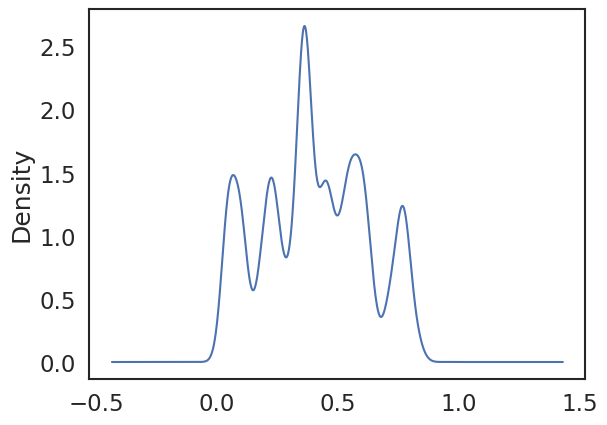

In [6]:
df["coverage"].plot.kde()

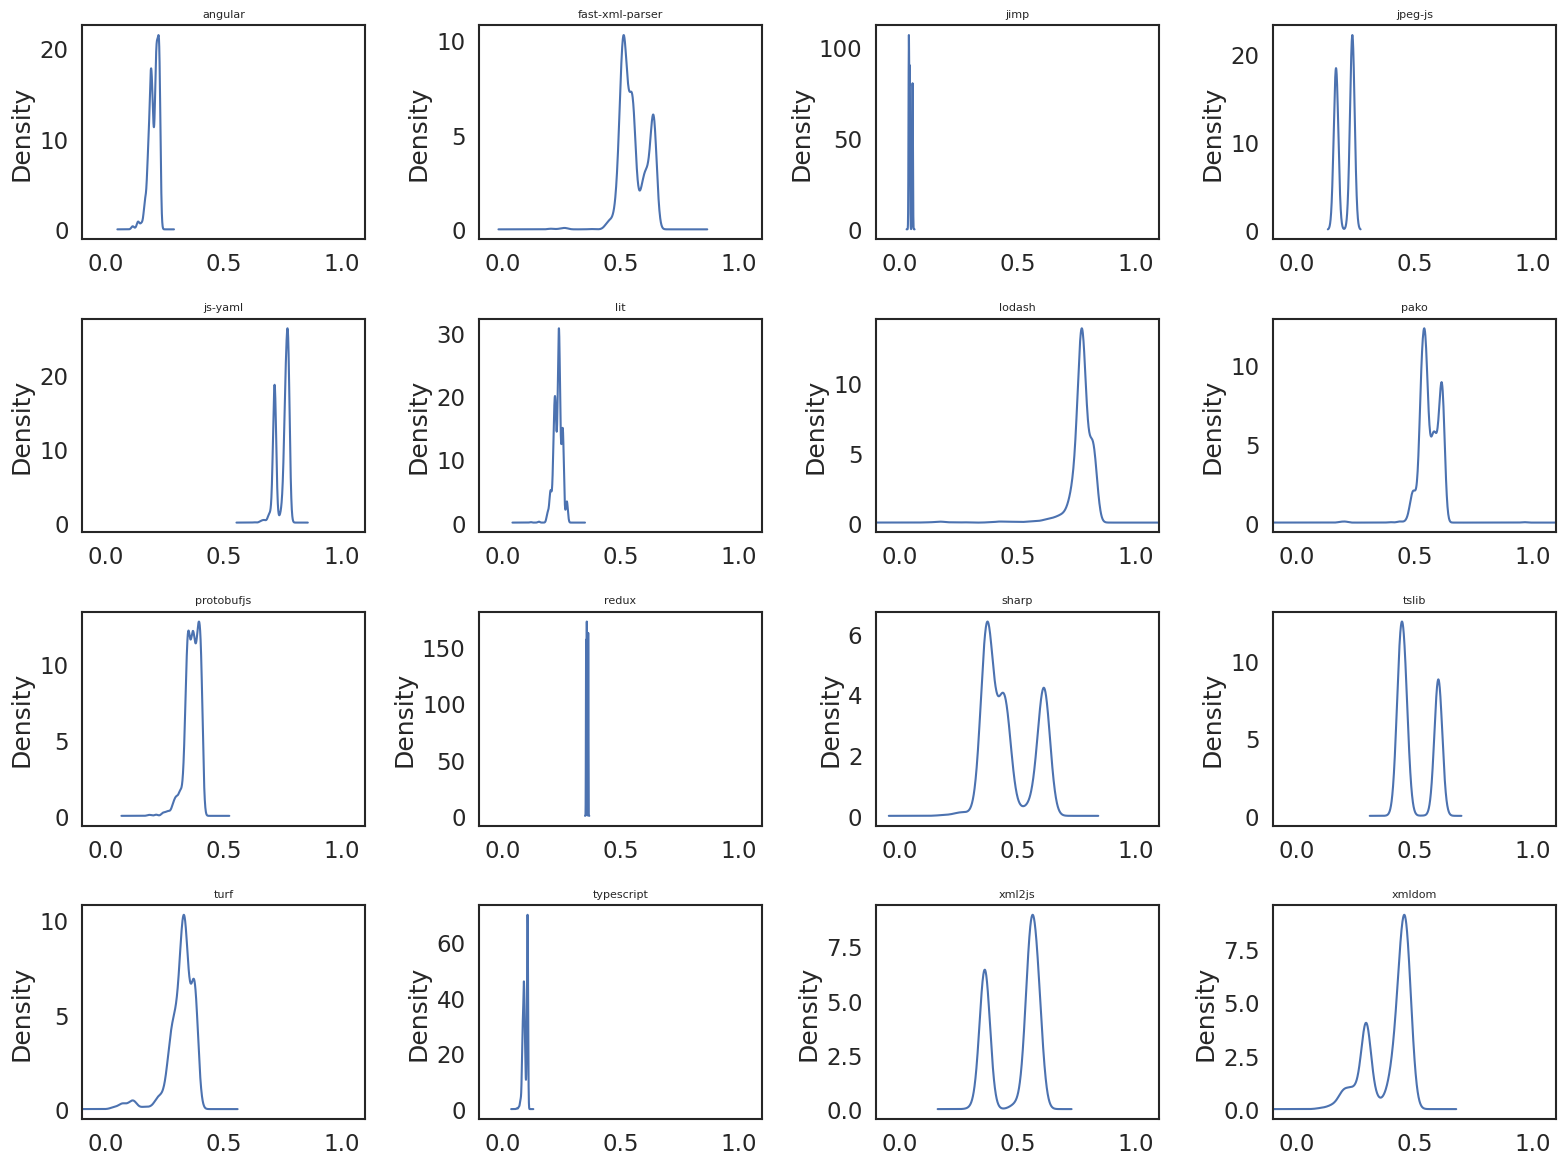

In [7]:
projects = df["project"].unique()
n = len(projects)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()

for i, proj in enumerate(sorted(projects)):
    df[df["project"] == proj]["coverage"].plot.kde(ax=axes[i])
    axes[i].set_title(proj, fontsize=8)
    axes[i].set_xlim(-0.1, 1.1)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.tight_layout()